<a href="https://colab.research.google.com/github/bmurmann/ADC-survey/blob/main/plots/aperture_plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ADC Survey: Aperture Trend Plot

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
try:
    from google.colab import files
    IN_COLAB = True
except:
    IN_COLAB = False

In [40]:
# Read latest survey data and concatenate ISSCC and VLSI data
if IN_COLAB:
    data = "https://github.com/bmurmann/ADC-survey/blob/main/xls/ADCsurvey_latest.xlsx?raw=true"
else:
    data = "../xls/ADCsurvey_latest.xlsx"
df1 = pd.read_excel(data, sheet_name='ISSCC')
df2 = pd.read_excel(data, sheet_name='VLSI')
df = pd.concat([df1, df2])

In [41]:
# Show headers of data table
print(df.keys())

Index(['YEAR', 'ID', 'TYPE', 'ARCHITECTURE', 'TECHNOLOGY', 'TITLE', 'ABSTRACT',
       'AUTHORS', 'DOI', 'LINK', 'COMMENTS', 'VSUP1 [V]', 'VSUP2 [V]',
       'VSUP3 [V]', 'Csamp [pF]', 'AREA [mm^2]', 'SNDR_lf [dB]', 'fin_hf [Hz]',
       'SNDR_hf [dB]', 'SNR [dB]', 'DR [dB]', '-THD [dB]', 'SFDR [dB]',
       'SNDR_plot [dB]', 'P [W]', 'fs [Hz]', 'OSR', 'fsnyq [Hz]',
       'fcenter [Hz]', 'P/fsnyq [pJ]', 'FOMW_lf [fJ/conv-step]',
       'FOMW_hf [fJ/conv-step]', 'FOMS_lf [dB]', 'FOMS_hf [dB]',
       'FOMW_hf/fsnyq', 'FOMS,hf+10log(fsnyq)'],
      dtype='object')


In [42]:
# Compute aperture envelope in each year
num_avg = 2
fin_hf = np.array(df['fin_hf [Hz]'])
sndr_hf = np.array(df['SNDR_hf [dB]'])
year = np.array(df['YEAR'])
year_range = np.arange(np.min(year), np.max(year) + 1)
jitter_asymp = np.zeros(len(year_range))

# Compute averages using dB numbers to attenuate annual outliers
for i in range(len(year_range)):
  idx = np.where(year <= year_range[i])
  jitter_estimate = 1/(2*np.pi*fin_hf[idx] * np.sqrt(10**(sndr_hf[idx]/10)))
  smallest = sorted(jitter_estimate, key = lambda x : float('inf') if np.isnan(x) else x)[:num_avg]
  jitter_asymp[i] = np.mean(smallest)

In [43]:
# Decent settings for a PowerPoint figure
font=16
size=(8, 5)

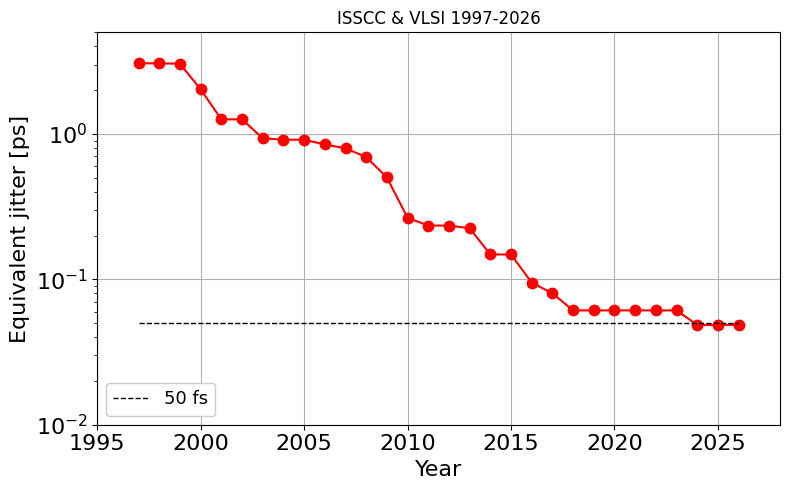

In [44]:
fig, ax = plt.subplots(figsize=size)
ax.plot(year_range, jitter_asymp*1e12, 'r.-', ms=15)
ax.plot(year_range, np.ones_like(year_range)*0.05, 'k--', linewidth=1, label='50 fs')
ax.legend(frameon=1, loc='lower left', framealpha=1.0, fontsize=font-3)
ax.set_xlim((year_range[0]-2, year_range[-1]+2))
ax.set_ylim((0.01, 5))
plt.yscale('log')
plt.xticks(fontsize=font)
plt.yticks(fontsize=font)
plt.xlabel('Year', fontsize=font)
plt.ylabel('Equivalent jitter [ps]', fontsize=font)
plt.title('ISSCC & VLSI 1997-%d' %max(df['YEAR']))
plt.grid(True)
fig.tight_layout()
plt.show()

In [45]:
# save as high-resolution png file
if IN_COLAB:
   files.download('aperture_trend_plot.png')
else:
   fig.savefig("aperture_trend_plot.png", dpi=600)